DATA603: Principles of Machine Learning - Final Term Project

**A COMPREHENSIVE STUDY OF MACHINE LEARNING MODELS FOR CROSS-SITE SCRIPTING DETECTION**

*Name: Madhumitha Rajagopal*

*UID: 121331472*

##**TRANSFORMER MODEL**

This is the code snippet for the Transformer model on the XSS Dataset.

In [1]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import string
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import math

In [2]:
# Load and preprocess dataset
df = pd.read_csv("XSS_dataset.csv", index_col=0)
train_df = df[:int(len(df) * 0.8)]
test_df = df[int(len(df) * 0.8):]

In [3]:
df.head()

,Sentence,Label
0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,"\t </span> <span class=""reference-text"">Steeri...",0
3,"\t </span> <span class=""reference-text""><cite ...",0
4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [4]:
# Define character-to-index mapping
def find_character(data, max_len):
    alphabet = string.ascii_lowercase + string.digits + string.punctuation + " "
    mat = [alphabet.index(ch) if ch in alphabet else 0 for ch in data]
    mat = mat[:max_len] + [0] * (max_len - len(mat))
    return mat

In [5]:
# Dataset class
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df, max_len):
        self.df = df
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        sentence = self.df["Sentence"].values[index]
        label = self.df["Label"].values[index]
        return torch.tensor(find_character(sentence, self.max_len)), torch.tensor(label)


In [6]:
# Prepare data loaders
train_dataset = Dataset(train_df, max_len=1000)
test_dataset = Dataset(test_df, max_len=1000)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

In [7]:
# Positional encoding class
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

In [8]:
# Transformer model class
class CustomTransformerModel(nn.Module):
    def __init__(self, vocab_size, embedding_size, num_classes, nhead, num_layers, dim_feedforward, dropout):
        super(CustomTransformerModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.pos_encoder = PositionalEncoding(embedding_size, dropout)
        encoder_layers = TransformerEncoderLayer(embedding_size, nhead, dim_feedforward, dropout)
        self.transformer_encoder = TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(embedding_size, num_classes)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()
        self.fc.weight.data.uniform_(-initrange, initrange)

    def forward(self, x):
        embedded = self.embedding(x).permute(1, 0, 2)
        embedded = self.pos_encoder(embedded)
        output = self.transformer_encoder(embedded)
        output = output.mean(dim=0)  # Average pooling
        return self.fc(output)

In [9]:
# Model initialization
vocab_size = len(string.ascii_lowercase + string.digits + string.punctuation + " ")
model = CustomTransformerModel(
    vocab_size=vocab_size,
    embedding_size=64,
    num_classes=2,
    nhead=8,
    num_layers=3,
    dim_feedforward=128,
    dropout=0.1,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


CustomTransformerModel(
  (embedding): Embedding(69, 64)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

In [10]:
# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
epochs = 10

In [11]:
# Training loop
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for data, label in tqdm(train_loader):
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

100%|██████████| 86/86 [01:19<00:00,  1.08it/s]


Epoch 1/10, Loss: 58.9174


100%|██████████| 86/86 [01:21<00:00,  1.05it/s]


Epoch 2/10, Loss: 46.0318


100%|██████████| 86/86 [01:21<00:00,  1.05it/s]


...

Epoch 8/10, Loss: 1.1228


100%|██████████| 86/86 [01:21<00:00,  1.05it/s]


Epoch 9/10, Loss: 0.8791


100%|██████████| 86/86 [01:21<00:00,  1.05it/s]

Epoch 10/10, Loss: 0.9247


In [12]:
# Evaluation
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, label in loader:
            data, label = data.to(device), label.to(device)
            output = model(data)
            pred = torch.argmax(output, dim=1)
            correct += (pred == label).sum().item()
    return correct / len(loader.dataset)

In [13]:
accuracy = evaluate_model(model, test_loader)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 99.63%


In [14]:
# Save the model
torch.save(model.state_dict(), "transformer_model.pth")

In [15]:
# Prediction function
def predict(sentence, model):
    model.eval()
    with torch.no_grad():
        data = torch.tensor(find_character(sentence, 1000)).unsqueeze(0).to(device)
        output = model(data).argmax(dim=1)
        return output.item()

In [16]:
# Load model for inference
loaded_model = CustomTransformerModel(
    vocab_size=vocab_size,
    embedding_size=64,
    num_classes=2,
    nhead=8,
    num_layers=3,
    dim_feedforward=128,
    dropout=0.1,
)
loaded_model.load_state_dict(torch.load("transformer_model.pth", map_location=device))
loaded_model.to(device)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
<ipython-input-16-5aa91c32f3f9>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you st

CustomTransformerModel(
  (embedding): Embedding(69, 64)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

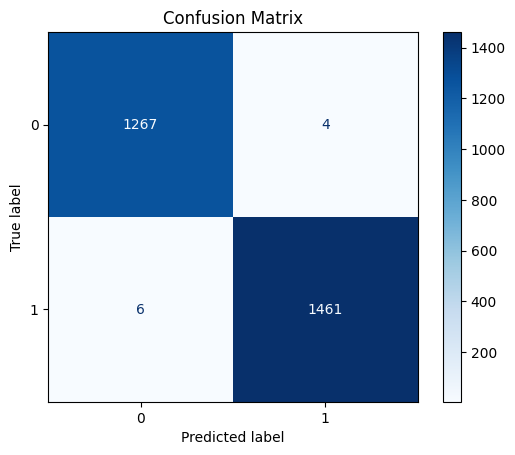

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on validation set
y_pred = [predict(sentence, model) for sentence in test_df['Sentence']]
y_pred = (np.array(y_pred) > 0.5).astype("int32")

y_val = test_df['Label'].values

# Generate confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Example prediction
sentence = "test input for prediction"
print(f"Predicted label: {predict(sentence, loaded_model)}")

Predicted label: 0


In [20]:
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score

# Example model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  # Flatten the input images
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Example data
(X_train, y_train), (X_val, y_val) = tf.keras.datasets.mnist.load_data()
X_train, X_val = X_train / 255.0, X_val / 255.0  # Normalize data
y_train, y_val = y_train == 1, y_val == 1  # Example binary classification for '1' class

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=5)

# Extract metrics from history
metrics = {
    "Accuracy": history.history['accuracy'][-1],
    "Validation Accuracy": history.history['val_accuracy'][-1],
    "Loss": history.history['loss'][-1],
    "Validation Loss": history.history['val_loss'][-1]
}

# Predict on validation set for precision and recall
y_pred = (model.predict(X_val) > 0.5).astype("int32")

metrics["Precision"] = precision_score(y_val, y_pred)
metrics["Recall"] = recall_score(y_val, y_pred)

# Display metrics
import pandas as pd
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print(metrics_df)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9805 - loss: 0.0526 - val_accuracy: 0.9967 - val_loss: 0.0120
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9961 - loss: 0.0131 - val_accuracy: 0.9973 - val_loss: 0.0123
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9972 - loss: 0.0083 - val_accuracy: 0.9971 - val_loss: 0.0100
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9984 - loss: 0.0053 - val_accuracy: 0.9978 - val_loss: 0.0083
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9983 - loss: 0.0049 - val_accuracy: 0.9977 - val_loss: 0.0082
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
                Metric     Value
0             Accuracy  0.998383
1  Validation Accuracy  0.997700
2                 Loss  0.004726
3      Validation Loss  0.008155
4            Precision  0.994662
5               Recall  0.985022
